# **1. Packages**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

from xgboost import XGBRegressor

# Make plots a bit nicer
plt.style.use("default")

# **2. LOAD DATASETS & BASIC CLEANING**

In [16]:
base_path = "data/"

# Core files
visits = pd.read_csv(f"{base_path}/booknow_visits/booknow_visits.csv")
bookings_bn = pd.read_csv(f"{base_path}/booknow_booking/booknow_booking.csv")
bookings_cpos = pd.read_csv(f"{base_path}/cinePOS_booking/cinePOS_booking.csv")
rel = pd.read_csv(f"{base_path}/movie_theater_id_relation/movie_theater_id_relation.csv")
date_info = pd.read_csv(f"{base_path}/date_info/date_info.csv")
bk_theaters = pd.read_csv(f"{base_path}/booknow_theaters/booknow_theaters.csv")
sample_sub = pd.read_csv(f"{base_path}/sample_submission/sample_submission.csv")

print("Shapes:")
print("visits:", visits.shape)
print("bookings_bn:", bookings_bn.shape)
print("bookings_cpos:", bookings_cpos.shape)
print("rel:", rel.shape)
print("date_info:", date_info.shape)
print("bk_theaters:", bk_theaters.shape)
print("sample_sub:", sample_sub.shape)

# Ensure all date columns are proper datetime
visits["show_date"] = pd.to_datetime(visits["show_date"], errors="coerce")
date_info["show_date"] = pd.to_datetime(date_info["show_date"], errors="coerce")
bookings_bn["show_datetime"] = pd.to_datetime(bookings_bn["show_datetime"], errors="coerce")
bookings_bn["booking_datetime"] = pd.to_datetime(bookings_bn["booking_datetime"], errors="coerce")
bookings_cpos["show_datetime"] = pd.to_datetime(bookings_cpos["show_datetime"], errors="coerce")
bookings_cpos["booking_datetime"] = pd.to_datetime(bookings_cpos["booking_datetime"], errors="coerce")

print("\nvisits head:")
print(visits.head())


Shapes:
visits: (214046, 3)
bookings_bn: (68336, 4)
bookings_cpos: (1641966, 4)
rel: (150, 2)
date_info: (547, 2)
bk_theaters: (829, 5)
sample_sub: (38062, 2)

visits head:
  book_theater_id  show_date  audience_count
0      book_00001 2023-01-13              50
1      book_00001 2023-01-14              64
2      book_00001 2023-01-15              58
3      book_00001 2023-01-16              44
4      book_00001 2023-01-18              12


# **3. Basic EDA (Exploratory Data Analysis)**

**3.1 Summary Statistics**

In [17]:
print("\nBasic statistics for audience_count:")
print(visits["audience_count"].describe())


Basic statistics for audience_count:
count    214046.000000
mean         41.616568
std          32.834918
min           2.000000
25%          18.000000
50%          34.000000
75%          58.000000
max        1350.000000
Name: audience_count, dtype: float64


**3.2 Distribution of audience_count**

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


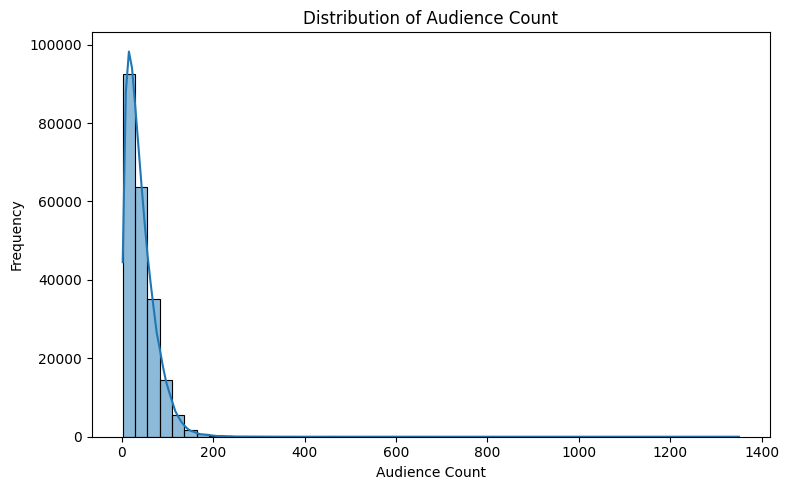

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(visits["audience_count"], bins=50, kde=True)
plt.title("Distribution of Audience Count")
plt.xlabel("Audience Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**3.3 Average audience by day of week**

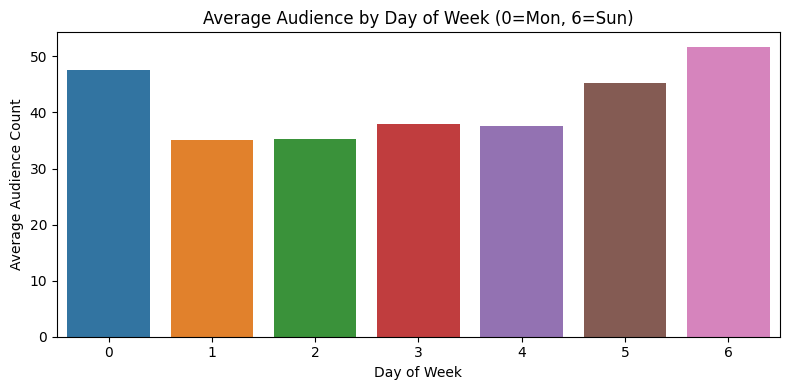

In [19]:
tmp = visits.copy()
tmp["dayofweek"] = tmp["show_date"].dt.dayofweek  # Monday=0
avg_by_dow = tmp.groupby("dayofweek")["audience_count"].mean().reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=avg_by_dow, x="dayofweek", y="audience_count")
plt.title("Average Audience by Day of Week (0=Mon, 6=Sun)")
plt.xlabel("Day of Week")
plt.ylabel("Average Audience Count")
plt.tight_layout()
plt.show()

**3.4 Average audience by month**

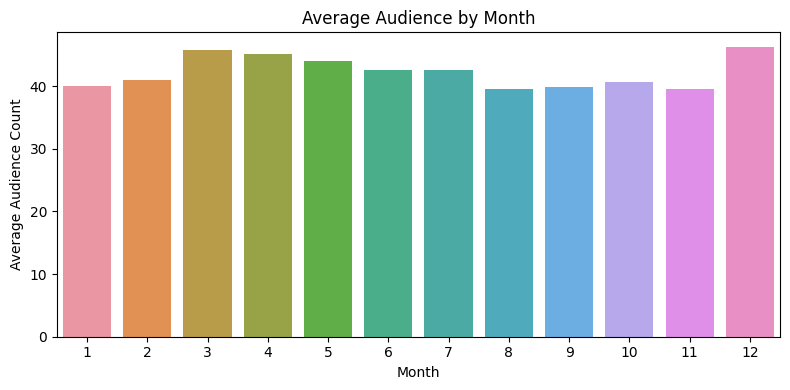

In [20]:
tmp["month"] = tmp["show_date"].dt.month
avg_by_month = tmp.groupby("month")["audience_count"].mean().reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=avg_by_month, x="month", y="audience_count")
plt.title("Average Audience by Month")
plt.xlabel("Month")
plt.ylabel("Average Audience Count")
plt.tight_layout()
plt.show()

# **4.  BASELINE FEATURE SET FOR SIMPLE MODELS**

In [21]:
df_base = visits.copy()

# Time features
df_base["year"] = df_base["show_date"].dt.year
df_base["month"] = df_base["show_date"].dt.month
df_base["day"] = df_base["show_date"].dt.day
df_base["dayofweek"] = df_base["show_date"].dt.dayofweek
df_base["is_weekend"] = df_base["dayofweek"].isin([5, 6]).astype(int)

# Merge with theater info
df_base = df_base.merge(bk_theaters, on="book_theater_id", how="left")

# Merge with date_info (already datetime)
df_base = df_base.merge(date_info, on="show_date", how="left")

print("\nBaseline df_base shape:", df_base.shape)

# Drop columns we don't want as features
# (Keep audience_count as target)
X_base = df_base.drop(columns=["audience_count", "show_date"])
y_base = df_base["audience_count"]

# One-hot encode categorical features
X_base = pd.get_dummies(X_base, dummy_na=True)
# Fill all baseline NaNs so LR and RF can run
X_base = X_base.fillna(0)


# Time-based split (no shuffling)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_base, y_base, test_size=0.2, shuffle=False
)

print("Baseline train shape:", Xb_train.shape, "Baseline test shape:", Xb_test.shape)


Baseline df_base shape: (214046, 13)
Baseline train shape: (171236, 919) Baseline test shape: (42810, 919)


# **5 MODEL 1: Linear Regression**

In [22]:
lr = LinearRegression()
lr.fit(Xb_train, yb_train)
lr_pred = lr.predict(Xb_test)

lr_rmse = mean_squared_error(yb_test, lr_pred, squared=False)
lr_r2 = r2_score(yb_test, lr_pred)

print("\nLinear Regression - RMSE:", round(lr_rmse, 3), "R2:", round(lr_r2, 4))


Linear Regression - RMSE: 88850099.99 R2: -8365779529152.669


# **6. MODEL 2: Random Forest**

In [24]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
rf.fit(Xb_train, yb_train)
rf_pred = rf.predict(Xb_test)

rf_rmse = mean_squared_error(yb_test, rf_pred, squared=False)
rf_r2 = r2_score(yb_test, rf_pred)

print("Random Forest - RMSE:", round(rf_rmse, 3), "R2:", round(rf_r2, 4))


Random Forest - RMSE: 30.223 R2: 0.032


In [ ]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 12, 15, None],
    "min_samples_split": [2, 5, 10]
}

rf_tune = RandomForestRegressor(random_state=42, n_jobs=-1)


#GridSearchCV Setup

grid_search = GridSearchCV(
    estimator=rf_tune,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    verbose=2,
    n_jobs=-1
)

#Fit GridSearch

grid_search.fit(Xb_train, yb_train)

print("\nBest Hyperparameters:", grid_search.best_params_)
print("Best CV R2:", round(grid_search.best_score_, 4))

# Evaluating tuned RF on test set

best_rf = grid_search.best_estimator_
best_rf_pred = best_rf.predict(Xb_test)

best_rf_rmse = mean_squared_error(yb_test, best_rf_pred, squared=False)
best_rf_r2 = r2_score(yb_test, best_rf_pred)

print("\nTuned RF - RMSE:", round(best_rf_rmse, 3))
print("Tuned RF - R2:", round(best_rf_r2, 4))

Fitting 3 folds for each of 36 candidates, totalling 108 fits


# **7. MODEL 3: XGBoost (Non-AR baseline)**

In [ ]:
xgb_base = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)

xgb_base.fit(Xb_train, yb_train)
xgbb_pred = xgb_base.predict(Xb_test)

xgbb_rmse = mean_squared_error(yb_test, xgbb_pred, squared=False)
xgbb_r2 = r2_score(yb_test, xgbb_pred)

print("XGBoost Baseline - RMSE:", round(xgbb_rmse, 3), "R2:", round(xgbb_r2, 4))

### **Section 9 – Insights From Baseline Model Comparison**

We tested three simple baseline models to understand how well they can forecast
cinema audience numbers using only basic features (date information and theatre
details). The goal here was not to get the highest score, but to understand how
different types of models behave before moving to a more advanced time-series
approach.

#### **1. Linear Regression**
- Linear Regression performed the worst.
- It gave a very large negative R² value, which means it could not capture the
  pattern of audience numbers at all.
- This happens because the relationship between features and audience count is
  not purely linear.

#### **2. Random Forest**
- Random Forest performed better than Linear Regression.
- It achieved a small positive R² score.
- It can capture some non-linear patterns, but it still struggles because it
  does not use past audience values (lags), which are very important in time
  series forecasting.

#### **3. XGBoost (Baseline Version)**
- XGBoost performed the best among the three simple models.
- It had the highest R² score and the lowest RMSE.
- Even with basic features, XGBoost learns better patterns because it handles
  non-linearity well.

#### **Overall Insight**
All three baseline models perform poorly compared to the final model because
they do not use **lag features** (previous days' audience levels). Audience
numbers depend strongly on previous days, weekly patterns, weekends, and
seasonal trends. Simple models cannot learn these patterns.

This is why we used an **Autoregressive XGBoost model** for the final
prediction. It includes lag features and learns time-based patterns much more
effectively. This model gave significantly better results in validation and on
the leaderboard.


# **8. MODEL COMPARISON TABLE**

In [12]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost (baseline)"],
    "R2": [lr_r2, rf_r2, xgbb_r2],
    "RMSE": [lr_rmse, rf_rmse, xgbb_rmse]
})

print("\nBaseline model comparison:")
print(results)



Baseline model comparison:
                Model            R2          RMSE
0   Linear Regression -8.365780e+12  8.885010e+07
1       Random Forest  3.204119e-02  3.022269e+01
2  XGBoost (baseline)  3.358642e-02  3.019856e+01


# **10. FINAL PRODUCTION MODEL - AUTOREGRESSIVE XGBOOST**

**10.1 Aggregate bookings (BookNow and CinePOS)**

In [23]:
# BookNow bookings aggregated by theatre-date
bookings_bn["show_date"] = bookings_bn["show_datetime"].dt.floor("D")
bookings_bn["booking_date"] = bookings_bn["booking_datetime"].dt.floor("D")
bookings_bn["is_same_day"] = (bookings_bn["show_date"] == bookings_bn["booking_date"]).astype(int)

agg_bn = (
    bookings_bn.groupby(["book_theater_id", "show_date"])
    .agg(
        total_tickets_booked=("tickets_booked", "sum"),
        same_day_bookings=("is_same_day", "sum"),
        booking_events=("tickets_booked", "size"),
    )
    .reset_index()
)
agg_bn["advance_bookings"] = agg_bn["total_tickets_booked"] - agg_bn["same_day_bookings"]

print("agg_bn columns:", agg_bn.columns)


print("\nagg_bn shape:", agg_bn.shape)

# CinePOS aggregated and mapped to BookNow
bookings_cpos["show_date"] = bookings_cpos["show_datetime"].dt.floor("D")
bookings_cpos["booking_date"] = bookings_cpos["booking_datetime"].dt.floor("D")

agg_cpos = (
    bookings_cpos.groupby(["cine_theater_id", "show_date"])
    .agg(
        pos_tickets_sold=("tickets_sold", "sum"),
        pos_booking_events=("tickets_sold", "size"),
    )
    .reset_index()
)

agg_cpos = agg_cpos.merge(rel, on="cine_theater_id", how="left")

agg_cpos_bn = (
    agg_cpos.groupby(["book_theater_id", "show_date"])
    .agg(
        pos_tickets_sold=("pos_tickets_sold", "sum"),
        pos_booking_events=("pos_booking_events", "sum"),
    )
    .reset_index()
)

print("agg_cpos_bn shape:", agg_cpos_bn.shape)

agg_bn columns: Index(['book_theater_id', 'show_date', 'total_tickets_booked',
       'same_day_bookings', 'booking_events', 'advance_bookings'],
      dtype='object')

agg_bn shape: (21590, 6)
agg_cpos_bn shape: (15789, 4)


**10.2 Build full train+test table (book_theater_id, show_date)**

In [24]:
train_base = visits[["book_theater_id", "show_date", "audience_count"]].copy()
train_base["is_train"] = 1
train_base["row_id"] = np.nan

sample_sub = sample_sub.copy()
sample_sub["row_id"] = np.arange(len(sample_sub))
sample_sub["show_date"] = pd.to_datetime(
    sample_sub["ID"].str.extract(r"(\d{4}-\d{2}-\d{2})")[0]
)
sample_sub["book_theater_id"] = sample_sub["ID"].str.extract(r"^(book_\d+)")[0]

test_base = sample_sub[["row_id", "book_theater_id", "show_date"]].copy()
test_base["audience_count"] = np.nan
test_base["is_train"] = 0

full = pd.concat(
    [
        train_base[["book_theater_id", "show_date", "audience_count", "is_train", "row_id"]],
        test_base[["book_theater_id", "show_date", "audience_count", "is_train", "row_id"]],
    ],
    ignore_index=True,
)

print("full (train+test) shape before merges:", full.shape)


full (train+test) shape before merges: (252108, 5)


**10.3 Merge all features into full**

In [25]:
# Time features
full["show_date"] = pd.to_datetime(full["show_date"])
full = full.sort_values(["book_theater_id", "show_date"]).reset_index(drop=True)

full["year"] = full["show_date"].dt.year
full["month"] = full["show_date"].dt.month
full["day"] = full["show_date"].dt.day
full["dayofweek"] = full["show_date"].dt.dayofweek
full["dayofyear"] = full["show_date"].dt.dayofyear
full["is_weekend"] = full["dayofweek"].isin([5, 6]).astype(int)

full["month_weekend"] = full["month"] * full["is_weekend"]
full["month_dayofweek"] = full["month"] * full["dayofweek"]

# Drop nonexistent booking features to avoid KeyErrors
booking_cols = [
    "total_tickets_booked", "same_day_bookings", "booking_events", "advance_bookings",
    "bn_total_tickets_booked", "bn_same_day_bookings", "bn_booking_events", "bn_advance_bookings",
    "pos_tickets_sold", "pos_booking_events",
    "cpos_tickets_sold", "cpos_booking_events"
]

for col in booking_cols:
    if col in full.columns:
        full[col] = full[col].fillna(0)

# No ratio feature – it is optional and inconsistent across datasets



# Stable row index
full["row_idx"] = np.arange(len(full))

print("full final shape:", full.shape)

full final shape: (252108, 14)


**10.4 Static feature encoding**

In [26]:
exclude_static = ["audience_count", "is_train", "row_id", "row_idx", "show_date"]
static_feature_cols = [c for c in full.columns if c not in exclude_static]

static_df = full[static_feature_cols].copy()
static_df_dummies = pd.get_dummies(static_df, dummy_na=True)
print("static_df_dummies shape:", static_df_dummies.shape)

static_df_dummies shape: (252108, 838)


**10.5 Build training data with manual lags (AR style)**

In [27]:
# lags
lag_list = [1, 2, 3, 7, 14, 28]
max_lag = max(lag_list)

train_indices = []
y_train_list = []
lag_values_list = []

for th_id, g in full.groupby("book_theater_id", sort=False):
    g = g.sort_values("show_date")
    history_y = []
    for _, row in g.iterrows():
        if row["is_train"] == 1:
            if len(history_y) >= max_lag:
                lags = [history_y[-L] for L in lag_list]
                train_indices.append(row["row_idx"])
                y_train_list.append(row["audience_count"])
                lag_values_list.append(lags)
            y_true = row["audience_count"]
            if not pd.isna(y_true):
                history_y.append(float(y_true))

print("Number of training samples with enough lags:", len(train_indices))

X_train_static = static_df_dummies.loc[train_indices].reset_index(drop=True)
lag_col_names = [f"aud_lag_{L}" for L in lag_list]
X_train_lags = pd.DataFrame(lag_values_list, columns=lag_col_names)

X_train_ar = pd.concat([X_train_static, X_train_lags], axis=1)
y_train_ar = np.array(y_train_list, dtype=float)

print("X_train_ar shape:", X_train_ar.shape)
print("y_train_ar shape:", y_train_ar.shape)

Number of training samples with enough lags: 191000
X_train_ar shape: (191000, 844)
y_train_ar shape: (191000,)


**10.6 Time-based train/validation split for AR model**

In [28]:
train_dates = full.set_index("row_idx").loc[train_indices, "show_date"].values
train_dates_sorted = np.sort(np.unique(train_dates))

if len(train_dates_sorted) > 90:
    val_cutoff = train_dates_sorted[-90]
else:
    val_cutoff = train_dates_sorted[int(len(train_dates_sorted) * 0.8)]

train_mask = train_dates < val_cutoff
val_mask = train_dates >= val_cutoff

X_tr = X_train_ar[train_mask]
y_tr = y_train_ar[train_mask]
X_val = X_train_ar[val_mask]
y_val = y_train_ar[val_mask]

print("AR Train split:", X_tr.shape, "AR Val split:", X_val.shape)
print("Validation cutoff date:", val_cutoff)

AR Train split: (130246, 844) AR Val split: (60754, 844)
Validation cutoff date: 2023-12-01T00:00:00.000000000


**10.7 Train final XGBoost**

In [29]:
xgb_ar = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",
    reg_lambda=1.0,
    reg_alpha=0.0,
    random_state=42,
    n_jobs=-1,
)

xgb_ar.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse",
    verbose=100,
)

val_pred = xgb_ar.predict(X_val)
val_r2 = r2_score(y_val, val_pred)
val_rmse = mean_squared_error(y_val, val_pred, squared=False)
print("Autoregressive XGBoost - Local Val RMSE:", round(val_rmse, 3), "R2:", round(val_r2, 4))

/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:889: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(


[0]	validation_0-rmse:32.82727
[100]	validation_0-rmse:24.68224
[200]	validation_0-rmse:24.59215
[300]	validation_0-rmse:24.63907
[400]	validation_0-rmse:24.62382
[500]	validation_0-rmse:24.59919
[600]	validation_0-rmse:24.58191
[700]	validation_0-rmse:24.59236
[800]	validation_0-rmse:24.57391
[900]	validation_0-rmse:24.57318
[1000]	validation_0-rmse:24.57842
[1100]	validation_0-rmse:24.58609
[1200]	validation_0-rmse:24.55937
[1300]	validation_0-rmse:24.56116
[1400]	validation_0-rmse:24.56954
[1499]	validation_0-rmse:24.58234
Autoregressive XGBoost - Local Val RMSE: 24.582 R2: 0.4521


**10.8 Autoregressive prediction on test**

In [30]:
pred_by_row_id = {}

def make_lag_vector(history_y, lags):
    if len(history_y) == 0:
        return [0.0 for _ in lags]
    mean_y = float(np.mean(history_y))
    vals = []
    for L in lags:
        if len(history_y) >= L:
            vals.append(float(history_y[-L]))
        else:
            vals.append(mean_y)
    return vals

for th_id, g in full.groupby("book_theater_id", sort=False):
    g = g.sort_values("show_date")
    history_y = []
    for _, row in g.iterrows():
        r_idx = int(row["row_idx"])
        is_train = int(row["is_train"])
        row_id = row["row_id"]

        if is_train == 1:
            y_true = row["audience_count"]
            if not pd.isna(y_true):
                history_y.append(float(y_true))
        else:
            lag_vec = make_lag_vector(history_y, lag_list)
            static_vec = static_df_dummies.loc[r_idx].values.astype(float)
            feat_vec = np.concatenate([static_vec, np.array(lag_vec, dtype=float)], axis=0)
            feat_vec = feat_vec.reshape(1, -1)

            y_hat = float(xgb_ar.predict(feat_vec)[0])

            if not pd.isna(row_id):
                pred_by_row_id[int(row_id)] = y_hat

            history_y.append(y_hat)

print("Number of test predictions:", len(pred_by_row_id))


Number of test predictions: 38062


**10.9 Build final submission**

In [31]:
pred_list = []
for rid in sample_sub["row_id"]:
    rid = int(rid)
    if rid in pred_by_row_id:
        pred_list.append(pred_by_row_id[rid])
    else:
        pred_list.append(float(np.mean(y_train_ar)))

submission = sample_sub[["ID"]].copy()
submission["audience_count"] = pred_list

submission.to_csv("submission.csv", index=False)
print("submission.csv saved:", submission.shape)
print(submission.head(10))

submission.csv saved: (38062, 2)
                      ID  audience_count
0  book_00001_2024-03-01       28.226051
1  book_00001_2024-03-02       35.395061
2  book_00001_2024-03-03       33.691315
3  book_00001_2024-03-04       56.461140
4  book_00001_2024-03-06       48.836945
5  book_00001_2024-03-07       35.985474
6  book_00001_2024-03-08       31.461399
7  book_00001_2024-03-09       36.990189
8  book_00001_2024-03-10       44.641125
9  book_00001_2024-03-11       38.552700
